In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
from models import Autoencoder
from utils import get_device, estandarizar_columnas_no_binarias, separar_columnas_binarias, crear_conjuntos_proporcionales, mostrar_resumen

df = pd.read_csv("../data/breast-cancer-wisconsin.csv")
print(df.shape)

# Quitamos atributos no necesarios
df = df.drop(columns=["id", "Unnamed: 32"])

# Reemplazamos los valores en diagnosis por 0 y 1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Estandarizamos las columnas no binarias
df = estandarizar_columnas_no_binarias(df)

# Dividimos nuestros conjuntos de datos
conjuntos = crear_conjuntos_proporcionales(df, "diagnosis", 0.2)

device = get_device()

# Desempaquetamos los conjuntos 0, 1, 2 y 3
x_train_0, x_test_0, y_train_0, y_test_0 = conjuntos[0]  # 0% de anómalos
x_train_1, x_test_1, y_train_1, y_test_1 = conjuntos[1]  # 10% de anómalos
x_train_2, x_test_2, y_train_2, y_test_2 = conjuntos[2]  # 25% de anómalos
x_train_3, x_test_3, y_train_3, y_test_3 = conjuntos[3]  # 50% de anómalos

mostrar_resumen(conjuntos)

(569, 33)
Dispositivo usado: cuda (NVIDIA GeForce GTX 970)

   Proporción  Positivos  Negativos  Total  % Positivos  % Negativos
0        0.00          0        170    170         0.00       100.00
1        0.10         17        153    170        10.00        90.00
2        0.25         42        128    170        24.71        75.29
3        0.50         85         85    170        50.00        50.00


In [2]:
x_train_0.shape

(170, 30)

Si se entrena un Autoencoder con un conjunto de datos $X$ (de entrenamiento) y luego se evalúa con un conjunto $T$ (de prueba) que sigue la misma distribución, se espera que:

$$
\lVert t'_1 - t_1 \rVert < \epsilon,
\qquad
t'_1 = \text{Decodificador}(\text{Codificador}(t_1)),
\qquad
t_1 \in T.
$$


In [3]:
from utils import evaluar_reconstruccion

#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-03T20.28_lr=0.01_set=0.pth", device=device) # buen modelo
#modelo = Autoencoder.load(path="../models/autoencoder_2025-12-03T23.50_lr=0.001_set=0.pth", device=device) # bueno también
modelo = Autoencoder.load(path="../models/autoencoder_2025-12-04T00.06_lr=0.001_set=0.pth", device=device) # buen modelo
modelo.summary()

X = x_test_0
Y = y_test_0

original = X[Y==0]

original, reconstruccion, diferencias = evaluar_reconstruccion(modelo, original, device)

print(f"Media {np.mean(diferencias)}")

print("\nArray original:")
print(original[0])
print("\nArray reconstruido:")
print(reconstruccion[0])


Modelo cargado correctamente de '../models/autoencoder_2025-12-04T00.06_lr=0.001_set=0.pth'
<Autoencoder: In 30 → 128 → 64 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 64 → 128 → 30 Out>
Media 3.471613620870803

Array original:
[-0.77107097 -1.96921136 -0.76665904 -0.71491618 -0.18702057 -0.70988499
 -0.67334978 -0.58472893 -0.52753026 -0.23619322 -0.95333544 -1.37071627
 -0.87200102 -0.65588964 -0.33337983 -0.56890981 -0.555015   -0.86481207
 -0.85917972 -0.60047666 -0.71363902 -1.57937135 -0.69998313 -0.6500019
  0.98243623 -0.09702164 -0.29712976 -0.38072922  0.18627607  0.07110148]

Array reconstruido:
[ 0.22998439 -1.2937894   0.19028462  0.10916832 -0.06808266 -0.26100624
 -0.26488194 -0.04756078 -0.2812449  -0.5893816  -0.3878358  -1.1656878
 -0.41553408 -0.28961152 -0.5593294  -0.55043787 -0.29091153 -0.09903197
 -0.68045926 -0.52572453  0.03202167 -1.4438294  -0.00192049 -0.08549258
 -0.43691483 -0.3851811  -0.2040214  -0.00170124 -0.6065009  -0.5977882 ]


c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


El valor de $\epsilon$ (epsilon) se calcula de la siguiente manera:

$$
\epsilon =
\begin{cases}
\max(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 0, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 1, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) + 2\,\operatorname{std}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 2.
\end{cases}
$$


Epsilon obtenido: 3.47


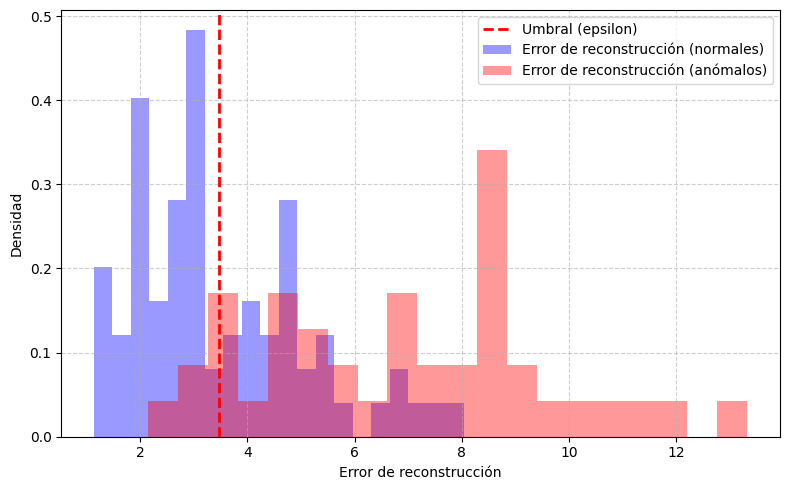

In [4]:
from utils import evaluar_reconstruccion, obtener_epsilon, obtener_matriz_confusion, obtener_metricas, graficar_matriz_confusion, graficar_histograma_errores_reconstruccion

_, _, dif_norm = evaluar_reconstruccion(modelo, X[Y==0], device)
_, _, dif_anom = evaluar_reconstruccion(modelo, X[Y==1], device)

epsilon = obtener_epsilon(dif_norm, tipo_epsilon=1)
print(f"Epsilon obtenido: {np.round(epsilon, 2)}")

graficar_histograma_errores_reconstruccion(dif_norm, dif_anom, epsilon=epsilon, kde=False, bins=20)

Luego las métricas se obtienen como:

$$
\begin{array}{rcl rcl}
\text{Accuracy} & = &
\dfrac{\text{TP} + \text{TN}}
      {\text{TP} + \text{FP} + \text{TN} + \text{FN}}
&
\text{Precision} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FP}}
\\[14pt]

\text{Recall} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FN}}
&
\text{Specificity} & = &
\dfrac{\text{TN}}
      {\text{TN} + \text{FP}}
\\[14pt]

\text{Balanced Accuracy} & = &
\dfrac{\dfrac{\text{TP}}{\text{TP}+\text{FN}} + \dfrac{\text{TN}}{\text{TN}+\text{FP}}}{2}
&
\text{F1\_Score} & = &
\dfrac{2\,\text{TP}}
      {2\,\text{TP} + \text{FP} + \text{FN}}
\end{array}
$$


En este caso veo más interesante analizar la métrica "precision" (creo que más importante) y "recall".

{'accuracy': 0.7193, 'precision': 0.5735, 'recall': 0.9286, 'specificity': 0.5972, 'balanced_accuracy': 0.7629, 'f1_score': 0.7091}


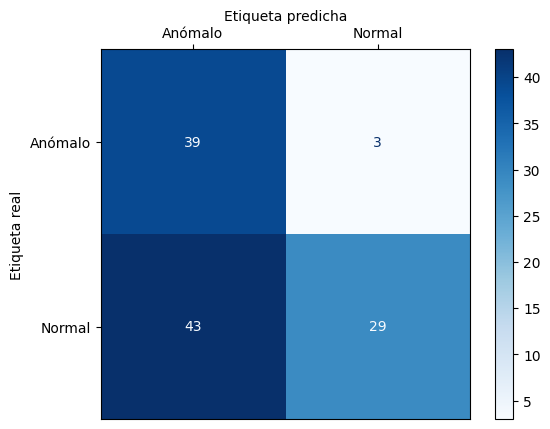

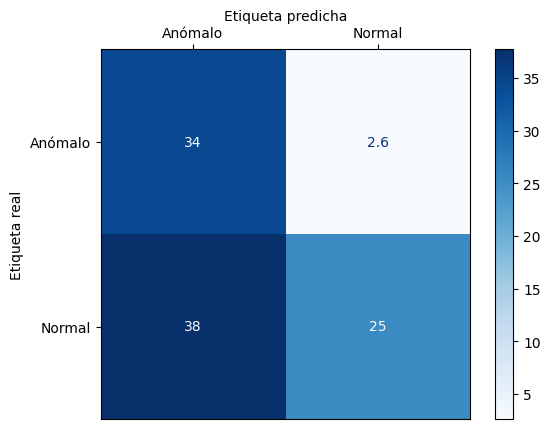

In [5]:
TP, FN, TN, FP = obtener_matriz_confusion(dif_norm, dif_anom, epsilon)
metricas = obtener_metricas(TP, FN, TN, FP)
print(metricas)
graficar_matriz_confusion(TP, FN, TN, FP)

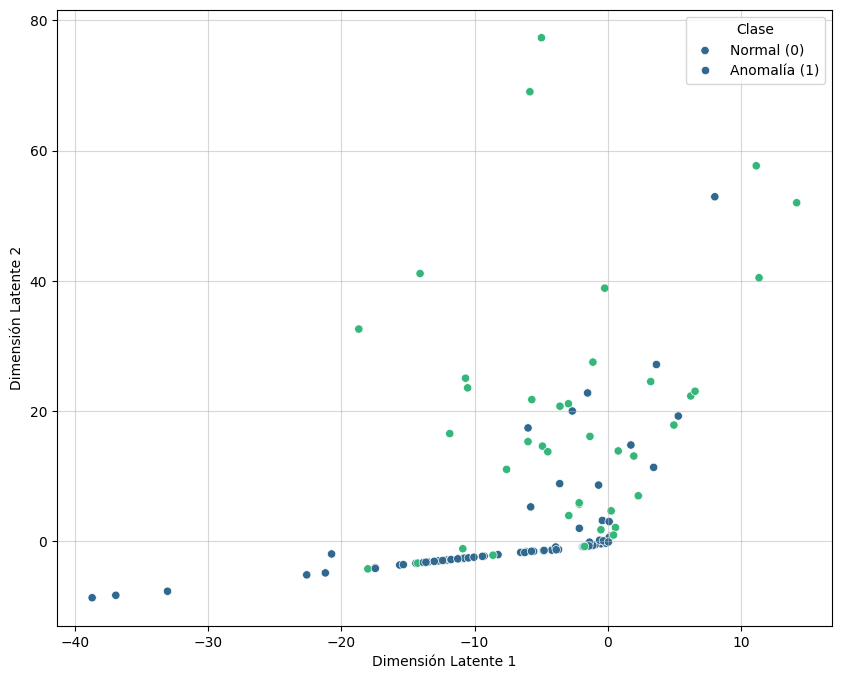

In [6]:
from utils import graficar_espacio_latente

z = modelo.encode(X, device)

graficar_espacio_latente(z, Y, ["Normal (0)", "Anomalía (1)"])